### Introduction to Linear Regression

Linear Regression is a fundamental supervised machine learning algorithm used for predicting a continuous target variable based on one or more input features. It assumes a linear relationship between the input features and the target variable.

**Simple Linear Regression** involves a single input feature (independent variable) and a continuous output variable (dependent variable). The relationship is modeled by a straight line:

$y = \theta_0 + \theta_1x + \epsilon$

Where:
- $y$ is the predicted value
- $x$ is the input feature
- $\theta_0$ is the y-intercept (bias)
- $\theta_1$ is the slope of the line (weight)
- $\epsilon$ is the error term (or irreducible error)

The goal of linear regression is to find the optimal values for $\theta_0$ and $\theta_1$ that minimize the sum of squared errors between the predicted and actual values.

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression #Builds a regression model
from sklearn.model_selection import train_test_split #Splita data into training and testing sets
from sklearn.metrics import mean_squared_error, r2_score #Measures the model accuracy
from sklearn.preprocessing import StandardScaler  #Normalizes data


In [9]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
print(df.head())
print(df.describe().round(2))
print("\nTarget name:",housing.target_names)


(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25% 

In [16]:
x = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

RMSE: 0.746
R²:   0.576


In [18]:
# Calculate the correlation of each feature with the target variable
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print("Correlation with MedHouseVal:\n", correlations)

Correlation with MedHouseVal:
 MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


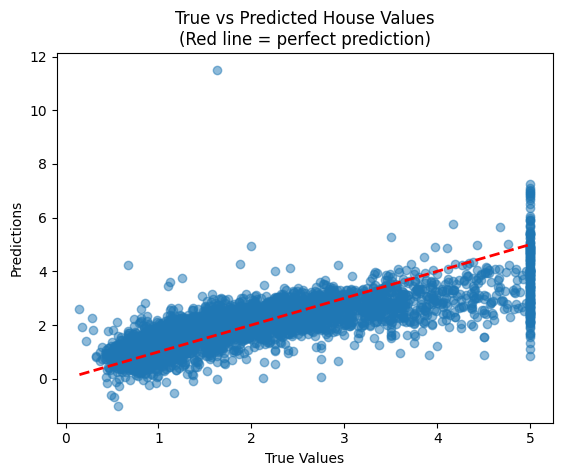

In [20]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted House Values\n(Red line = perfect prediction)")
plt.show()